# Type Inferencer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/type-inferencer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/type-inferencer/demo.ipynb)

> Every column landed as text. Typing them is easy. Typing them *without silently corrupting data* is the actual job.

**What this covers**

1. The problem: two casts that succeed and destroy data anyway
2. Rule one - **text-preserving**: the render must reproduce the source text
3. Rule two - **value-preserving**: the stored number must equal the number written
4. The third mechanism - **abstention**, for what no rule can settle
5. The engine, and the DDL it emits
6. The findings report: every column it refused to type, and why
7. Benchmark: all-TEXT vs a naive caster vs this, with `lossy` **measured** on the full column
8. Try your own CSV

*Fully offline - the corpus is generated, no database and no network needed.*

## 1. Two casts that succeed and destroy data anyway

A CSV lands. Every column is a string. Somebody has to write the `CREATE TABLE`, and the usual
approach is: try `int()`, then `float()`, then a date format, else text. It runs clean. It also
does this:

In [1]:
raw_zip = "01234"
print(f"zip:   {raw_zip!r}  ->  int  ->  {int(raw_zip)!r}   ... the identifier is now wrong")

raw_price = "10.10"
print(f"price: {raw_price!r}  ->  float ->  {float(raw_price)!r}  ... looks fine, so check the bits:")

from decimal import Decimal
print(f"       the float actually stores {Decimal(float(raw_price))}")
print(f"       you wrote                 {Decimal(raw_price)}")
print(f"       equal? {Decimal(float(raw_price)) == Decimal(raw_price)}")

zip:   '01234'  ->  int  ->  1234   ... the identifier is now wrong
price: '10.10'  ->  float ->  10.1  ... looks fine, so check the bits:
       the float actually stores 10.0999999999999996447286321199499070644378662109375
       you wrote                 10.10
       equal? False


No exception is raised in either case. The load succeeds, the dashboard renders, and the
defect surfaces months later as a mail-merge to the wrong postcode or a reconciliation that is
off by cents across ten million rows.

The fix is not a better parser. It is a **precondition**: cast only when the cast is reversible.

## 2. Rule one - text-preserving

For a string column becoming a narrow type, require that rendering the stored value reproduces
the source text **exactly**. One line, and the leading-zero trap is gone - along with `"+5"` and
`"1.0"`, which both cast to integers and both lose something on the way.

In [2]:
def int_roundtrips(raw: str) -> bool:
    """str(int(raw)) must give back exactly what was in the file."""
    try:
        return str(int(raw)) == raw
    except ValueError:
        return False


for v in ["1234", "01234", "+5", "1.0", "-42", "9007199254740993"]:
    verdict = "INTEGER" if int_roundtrips(v) else "stays text"
    print(f"  {v!r:22} {verdict}")

# Surrounding whitespace is the one documented exception: it is trimmed before inference,
# because it is a formatting artifact - but the engine files a warning saying the inferred
# type only holds if the loader trims on ingest too.
print(f"  {' 5'!r:22} trimmed first, with a warning - see `whitespace-padded` below")

  '1234'                 INTEGER
  '01234'                stays text
  '+5'                   stays text
  '1.0'                  stays text
  '-42'                  INTEGER
  '9007199254740993'     INTEGER
  ' 5'                   trimmed first, with a warning - see `whitespace-padded` below


## 3. Rule two - value-preserving

For numbers, require that the stored value equals the decimal number written in the file. A
binary float almost never does: `0.075`, `10.10` and `0.1` all land on a *nearby* binary
fraction. `DECIMAL(p,s)` stores them exactly.

This is why the rule matters more than the taste argument: "use DECIMAL for money" is advice you
can ignore, while a failing round-trip is a fact you cannot.

In [3]:
from decimal import Decimal


def double_is_value_preserving(raw: str) -> bool:
    """A float stores `raw` exactly only if its binary expansion equals the decimal written."""
    return Decimal(float(raw)) == Decimal(raw)


for v in ["10.10", "0.075", "0.5", "3.25", "0.1"]:
    ok = double_is_value_preserving(v)
    print(f"  {v!r:9} as DOUBLE -> {'exact' if ok else 'DRIFTS to ' + str(Decimal(float(v)))[:28] + '...'}")

  '10.10'   as DOUBLE -> DRIFTS to 10.0999999999999996447286321...
  '0.075'   as DOUBLE -> DRIFTS to 0.07499999999999999722444243...
  '0.5'     as DOUBLE -> exact
  '3.25'    as DOUBLE -> exact
  '0.1'     as DOUBLE -> DRIFTS to 0.10000000000000000555111512...


`0.5` and `3.25` survive - they are exact binary fractions. Everything else drifts. So the
ladder reaches `DOUBLE PRECISION` only where a column genuinely wants it, and money never
silently becomes a float.

## 4. The third mechanism - abstention

Some questions the data cannot answer, and both rules stay silent on them:

| Column | Why no rule settles it |
|---|---|
| `03/04/2026` where every component is <= 12 | DD/MM and MM/DD both parse, and they disagree about which day it is. The text round-trips either way. |
| a column of only `0` and `1` | flag, or a count that never exceeded one? |
| `"1,234.50"` | numeric in intent, not in form - typing it means rewriting the source text |

A parser guesses. This tool refuses and files a finding. The disambiguation it *can* do is
evidence-based: if any component exceeds 12, the order is settled by the data itself.

In [4]:
import re

SLASH = re.compile(r"^(\d{1,2})/(\d{1,2})/(\d{4})$")


def date_order(values):
    parts = [SLASH.match(v) for v in values]
    if not all(parts):
        return "not a slash date"
    day_first = any(int(p.group(1)) > 12 for p in parts)
    month_first = any(int(p.group(2)) > 12 for p in parts)
    if day_first and month_first:
        return "BLOCK - the column mixes both orders"
    if day_first:
        return "DATE as %d/%m/%Y  (a first component > 12 settles it)"
    if month_first:
        return "DATE as %m/%d/%Y  (a second component > 12 settles it)"
    return "ABSTAIN - both orders parse, kept as text"


print(date_order(["03/04/2026", "11/12/2026", "07/08/2026"]))
print(date_order(["25/04/2026", "03/11/2026"]))
print(date_order(["03/25/2026", "11/03/2026"]))
print(date_order(["25/04/2026", "03/25/2026"]))

ABSTAIN - both orders parse, kept as text
DATE as %d/%m/%Y  (a first component > 12 settles it)
DATE as %m/%d/%Y  (a second component > 12 settles it)
BLOCK - the column mixes both orders


## 5. The engine

The whole inference, in one cell so the notebook runs standalone. It is the same file as
[`type_infer.py`](type_infer.py) in the repo - the ladder (BOOLEAN -> integer widths -> temporal
-> DECIMAL -> VARCHAR -> TEXT), the abstention paths, the policy thresholds, the DDL emitter for
three dialects, and the naive strawman used in the benchmark.

Skim it or skip it - the next cells are what it does.

In [5]:
"""Infer SQL column types from raw text values - casting only when the cast is reversible.

Two guarantees, and the whole tool falls out of them:

1. TEXT-PRESERVING (string -> narrow type): rendering the stored value must reproduce
   the source text exactly. This is what kills the leading-zero trap ("01234" is not
   the integer 1234), along with "+5" and "1.0". Surrounding whitespace is the one
   documented exception: it is trimmed before inference, with a finding stating that
   the inferred type only holds if the loader trims too.

2. VALUE-PRESERVING (numeric types): the stored value must equal the decimal number
   written in the file, exactly. This is what refuses DOUBLE PRECISION for money -
   the binary float nearest "10.10" is 10.09999999999999964..., which is a different
   number, not a rounding detail.

Where the evidence cannot support a decision (an ambiguous DD/MM vs MM/DD column, a
0/1 column that could be a flag or a count, a thousands-separated amount), the tool
leaves the column as text and emits a finding saying why. Abstaining out loud beats
guessing silently.
"""

from __future__ import annotations

import re
from dataclasses import dataclass, field
from datetime import datetime
from decimal import Decimal, InvalidOperation
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

# --------------------------------------------------------------------------------------
# Policy
# --------------------------------------------------------------------------------------

DEFAULT_NULL_TOKENS = frozenset(
    {"", "null", "none", "n/a", "na", "nil", "-", "--", "unknown", "?", "\\n"}
)

TRUE_TOKENS = frozenset({"true", "t", "yes", "y"})
FALSE_TOKENS = frozenset({"false", "f", "no", "n"})

INT16_MAX = 32767
INT32_MAX = 2147483647
INT64_MAX = 9223372036854775807


@dataclass
class Policy:
    """Every threshold the inference leans on, in one place and visible in the UI."""

    null_tokens: frozenset = DEFAULT_NULL_TOKENS
    min_rows_for_not_null: int = 25       # below this, absence of NULL is not evidence
    min_rows_for_narrowing: int = 25      # below this, do not pick SMALLINT/enums
    varchar_block: int = 8                # round VARCHAR length up to a multiple of this
    varchar_max: int = 255                # above this, use TEXT
    enum_max_distinct: int = 12
    enum_max_ratio: float = 0.15          # distinct / non-null
    headroom_warn_ratio: float = 0.80     # observed max within 80% of type ceiling -> warn
    double_scale_hint: int = 5            # scale >= this looks like measurement, not money


# --------------------------------------------------------------------------------------
# Result types
# --------------------------------------------------------------------------------------

SEVERITY_ORDER = {"block": 0, "warn": 1, "info": 2}


@dataclass
class Finding:
    column: str
    code: str
    severity: str  # block | warn | info
    message: str

    def __str__(self) -> str:
        return f"[{self.severity.upper():5}] {self.column} - {self.code}\n        {self.message}"


@dataclass
class ColumnType:
    kind: str  # BOOLEAN INTEGER SMALLINT BIGINT DECIMAL DOUBLE DATE TIMESTAMP VARCHAR TEXT
    precision: Optional[int] = None
    scale: Optional[int] = None
    length: Optional[int] = None
    nullable: bool = True
    enum_values: Optional[List[str]] = None  # only ever a *suggestion*, never applied

    def sql(self, dialect: str = "postgres") -> str:
        k = self.kind
        if dialect == "sqlite":
            # SQLite has type affinity, not types. Collapse honestly.
            affinity = {
                "BOOLEAN": "INTEGER", "SMALLINT": "INTEGER", "INTEGER": "INTEGER",
                "BIGINT": "INTEGER", "DECIMAL": "NUMERIC", "DOUBLE": "REAL",
                "DATE": "TEXT", "TIMESTAMP": "TEXT", "VARCHAR": "TEXT", "TEXT": "TEXT",
            }
            return affinity[k]
        if k == "DECIMAL":
            name = "NUMERIC" if dialect == "postgres" else "DECIMAL"
            return f"{name}({self.precision},{self.scale})"
        if k == "DOUBLE":
            return "DOUBLE PRECISION" if dialect == "postgres" else "DOUBLE"
        if k == "VARCHAR":
            return f"VARCHAR({self.length})"
        return k

    def __str__(self) -> str:
        return self.sql("postgres")


@dataclass
class ColumnProfile:
    name: str
    n_rows: int
    n_null: int
    n_value: int
    distinct: int
    min_len: int
    max_len: int


@dataclass
class ColumnResult:
    name: str
    profile: ColumnProfile
    type: ColumnType
    findings: List[Finding] = field(default_factory=list)

    @property
    def abstained(self) -> bool:
        """True when the column was left as text *because* evidence was insufficient."""
        return self.type.kind in ("TEXT", "VARCHAR") and any(
            f.code in ABSTAIN_CODES for f in self.findings
        )


ABSTAIN_CODES = {
    "ambiguous-date-order", "date-order-conflict", "invalid-calendar-date",
    "thousands-separator", "sign-prefix", "padded-numeric", "single-valued-boolean",
    "no-observations",
}


# --------------------------------------------------------------------------------------
# Value-level helpers
# --------------------------------------------------------------------------------------


def is_null(raw: str, policy: Policy) -> bool:
    return raw.strip().lower() in policy.null_tokens


def int_roundtrips(raw: str) -> bool:
    """Text-preserving integer check: str(int(raw)) must reproduce raw exactly."""
    try:
        return str(int(raw)) == raw
    except (ValueError, TypeError):
        return False


def decimal_of(raw: str) -> Optional[Decimal]:
    try:
        d = Decimal(raw)
    except (InvalidOperation, ValueError, TypeError):
        return None
    if not d.is_finite():
        return None
    return d


def double_is_value_preserving(raw: str) -> bool:
    """A float stores raw exactly only if its binary expansion equals the decimal written."""
    d = decimal_of(raw)
    if d is None:
        return False
    try:
        return Decimal(float(raw)) == d
    except (OverflowError, ValueError):
        return False


def decimal_shape(values: Sequence[str]) -> Tuple[int, int]:
    """(precision, scale) that stores every value exactly."""
    max_scale = 0
    max_int_digits = 1
    for raw in values:
        d = decimal_of(raw)
        if d is None:
            continue
        exp = d.as_tuple().exponent
        digits = len(d.as_tuple().digits)
        scale = max(0, -int(exp))
        int_digits = max(1, digits + int(exp)) if exp < 0 else digits + int(exp)
        max_scale = max(max_scale, scale)
        max_int_digits = max(max_int_digits, int_digits)
    return max_int_digits + max_scale, max_scale


SLASH_DATE = re.compile(r"^(\d{1,2})/(\d{1,2})/(\d{4})$")
ISO_DATE = re.compile(r"^\d{4}-\d{2}-\d{2}$")
ISO_TS = re.compile(r"^\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}:\d{2}$")
THOUSANDS = re.compile(r"^-?\d{1,3}(,\d{3})+(\.\d+)?$")
SIGNED = re.compile(r"^\+\d+$")
PADDED = re.compile(r"^0\d+$")
DIGITS = re.compile(r"^\d+$")


def parses_with(raw: str, fmt: str) -> bool:
    """Text-preserving temporal check: the format must also *reproduce* the source text."""
    try:
        return datetime.strptime(raw, fmt).strftime(fmt) == raw
    except ValueError:
        return False


# --------------------------------------------------------------------------------------
# Per-kind candidates
# --------------------------------------------------------------------------------------


def try_boolean(values: Sequence[str]) -> Optional[ColumnType]:
    low = {v.strip().lower() for v in values}
    if not low or not low <= (TRUE_TOKENS | FALSE_TOKENS):
        return None
    if not (low & TRUE_TOKENS) or not (low & FALSE_TOKENS):
        return None  # a single-valued column is not evidence of a boolean
    return ColumnType("BOOLEAN")


def try_integer(values: Sequence[str], policy: Policy, n_rows: int) -> Optional[ColumnType]:
    if not all(int_roundtrips(v) for v in values):
        return None
    biggest = max(abs(int(v)) for v in values)
    if biggest <= INT16_MAX and n_rows >= policy.min_rows_for_narrowing:
        return ColumnType("SMALLINT")
    if biggest <= INT32_MAX:
        return ColumnType("INTEGER")
    if biggest <= INT64_MAX:
        return ColumnType("BIGINT")
    return None  # beyond int64 - fall through to DECIMAL


def try_decimal(values: Sequence[str]) -> Optional[ColumnType]:
    if any(decimal_of(v) is None for v in values):
        return None
    precision, scale = decimal_shape(values)
    return ColumnType("DECIMAL", precision=precision, scale=scale)


def try_temporal(values: Sequence[str], name: str) -> Tuple[Optional[ColumnType], List[Finding]]:
    findings: List[Finding] = []

    if all(parses_with(v, "%Y-%m-%d") for v in values) and all(ISO_DATE.match(v) for v in values):
        return ColumnType("DATE"), findings

    if all(ISO_TS.match(v) for v in values):
        for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%dT%H:%M:%S"):
            if all(parses_with(v, fmt) for v in values):
                return ColumnType("TIMESTAMP"), findings

    if all(SLASH_DATE.match(v) for v in values):
        firsts = [int(SLASH_DATE.match(v).group(1)) for v in values]
        seconds = [int(SLASH_DATE.match(v).group(2)) for v in values]
        day_first = any(a > 12 for a in firsts)
        month_first = any(b > 12 for b in seconds)
        if day_first and month_first:
            findings.append(Finding(
                name, "date-order-conflict", "block",
                "Some rows require DD/MM and others require MM/DD in the same column. "
                "The source is mixing two formats - no single date type is safe. Kept as text.",
            ))
            return None, findings
        if day_first or month_first:
            fmt = "%d/%m/%Y" if day_first else "%m/%d/%Y"
            if all(parses_with(v, fmt) for v in values):
                findings.append(Finding(
                    name, "date-order-resolved", "info",
                    f"Slash dates disambiguated as {fmt} by a component > 12 in the data.",
                ))
                return ColumnType("DATE"), findings
            findings.append(Finding(
                name, "invalid-calendar-date", "block",
                f"Order resolves to {fmt} but at least one value is not a real calendar date.",
            ))
            return None, findings
        findings.append(Finding(
            name, "ambiguous-date-order", "warn",
            "Every day and month component is <= 12, so DD/MM and MM/DD both parse and "
            "disagree on the actual dates. Kept as text - supply the source format instead "
            "of letting a loader pick one.",
        ))
        return None, findings

    return None, findings


def size_string(
    values: Sequence[str], policy: Policy, name: str, quiet: bool = False
) -> Tuple[ColumnType, List[Finding]]:
    """Size a string column. `quiet=True` for columns we are abstaining on - a column
    parked as text pending an upstream fix should not also collect enum advice."""
    findings: List[Finding] = []
    lengths = [len(v) for v in values]
    max_len, min_len = max(lengths), min(lengths)
    distinct = len(set(values))

    if max_len > policy.varchar_max:
        return ColumnType("TEXT"), findings

    if min_len == max_len:
        length = max_len
        if not quiet:
            findings.append(Finding(
                name, "fixed-width", "info",
                f"Every value is exactly {max_len} characters - a code format, not free text. "
                f"VARCHAR({max_len}) with no headroom; widen it if the format can change.",
            ))
    else:
        length = max(policy.varchar_block, -(-max_len // policy.varchar_block) * policy.varchar_block)
        if not quiet:
            findings.append(Finding(
                name, "length-is-a-sample-max", "info",
                f"Longest observed value is {max_len} chars; sized VARCHAR({length}). "
                "An observed maximum is not a specified maximum.",
            ))

    t = ColumnType("VARCHAR", length=length)
    if (
        not quiet
        and distinct <= policy.enum_max_distinct
        and distinct / max(1, len(values)) <= policy.enum_max_ratio
    ):
        t.enum_values = sorted(set(values))
        findings.append(Finding(
            name, "enum-candidate", "info",
            f"Only {distinct} distinct values across {len(values)} rows "
            f"({', '.join(repr(v) for v in t.enum_values)}). "
            "A CHECK constraint would catch new values at write time.",
        ))
    return t, findings


# --------------------------------------------------------------------------------------
# Column inference
# --------------------------------------------------------------------------------------


def infer_column(name: str, raw: Sequence[str], policy: Optional[Policy] = None) -> ColumnResult:
    policy = policy or Policy()
    n_rows = len(raw)
    values = [v for v in raw if not is_null(v, policy)]
    n_null = n_rows - len(values)

    pre_findings: List[Finding] = []
    n_padded_ws = sum(1 for v in values if v != v.strip())
    if n_padded_ws:
        # Surrounding whitespace is a formatting artifact, not data - but stripping it IS a
        # rewrite of the source, so the type below only holds if the loader also strips.
        pre_findings.append(Finding(
            name, "whitespace-padded", "warn",
            f"{n_padded_ws}/{len(values)} values carry leading or trailing whitespace. Inference "
            "ran on the trimmed values, so the inferred type only holds if the loader trims too "
            "(COPY ... , pandas `skipinitialspace`, or an explicit TRIM in the staging query).",
        ))
        values = [v.strip() for v in values]

    profile = ColumnProfile(
        name=name,
        n_rows=n_rows,
        n_null=n_null,
        n_value=len(values),
        distinct=len(set(values)),
        min_len=min((len(v) for v in values), default=0),
        max_len=max((len(v) for v in values), default=0),
    )
    findings: List[Finding] = list(pre_findings)

    if not values:
        findings.append(Finding(
            name, "no-observations", "warn",
            f"All {n_rows} values are null or a null sentinel. No type can be inferred; kept as text.",
        ))
        return ColumnResult(name, profile, ColumnType("TEXT", nullable=True), findings)

    nullable = n_null > 0
    if not nullable and n_rows < policy.min_rows_for_not_null:
        nullable = True
        findings.append(Finding(
            name, "thin-null-evidence", "warn",
            f"No nulls seen, but only {n_rows} rows (< {policy.min_rows_for_not_null}). "
            "Left nullable - absence of evidence is not evidence of NOT NULL.",
        ))

    # --- text shapes that a naive caster would silently swallow -----------------------
    n_padded = sum(1 for v in values if PADDED.match(v))
    if n_padded and all(DIGITS.match(v) for v in values):
        findings.append(Finding(
            name, "padded-numeric", "warn",
            f"{n_padded}/{len(values)} values are digits with a leading zero (zip code, account "
            "number, product code). The whole column casts to an integer cleanly and loses the "
            "padding forever - '01234' and '1234' are not the same identifier. Kept as text.",
        ))
        t, more = size_string(values, policy, name, quiet=True)
        t.nullable = nullable
        return ColumnResult(name, profile, t, findings + more)

    if any(THOUSANDS.match(v) for v in values):
        findings.append(Finding(
            name, "thousands-separator", "warn",
            "Values carry thousands separators (e.g. '1,234.50'). They are numeric in intent "
            "but not in form. Normalise upstream, then re-infer - this tool will not silently "
            "rewrite source text.",
        ))
        t, more = size_string(values, policy, name, quiet=True)
        t.nullable = nullable
        return ColumnResult(name, profile, t, findings + more)

    if any(SIGNED.match(v) for v in values):
        findings.append(Finding(
            name, "sign-prefix", "warn",
            "Some values carry an explicit '+' prefix. It casts to a number cleanly and the "
            "prefix is gone forever - harmless for a quantity, not harmless if the '+' is "
            "carrying meaning (a signed adjustment, a phone country code). Strip it upstream "
            "and re-infer. Kept as text.",
        ))
        t, more = size_string(values, policy, name, quiet=True)
        t.nullable = nullable
        return ColumnResult(name, profile, t, findings + more)

    # --- the ladder, narrow to wide ---------------------------------------------------
    boolean = try_boolean(values)
    if boolean is not None:
        boolean.nullable = nullable
        return ColumnResult(name, profile, boolean, findings)

    low = {v.strip().lower() for v in values}
    if low <= (TRUE_TOKENS | FALSE_TOKENS) and len(low) == 1:
        findings.append(Finding(
            name, "single-valued-boolean", "warn",
            f"Every value is {sorted(low)[0]!r}. That is consistent with a boolean but does not "
            "demonstrate one - a column that has only ever been true is not evidence the false "
            "case exists. Left as text; type it by hand if the source says it is a flag.",
        ))

    if set(values) == {"0", "1"}:
        findings.append(Finding(
            name, "zero-one-ambiguous", "warn",
            "Column holds only 0 and 1. That is a flag or a count of at-most-one - the data "
            "cannot tell which. Typed SMALLINT rather than BOOLEAN; confirm with the source owner.",
        ))

    integer = try_integer(values, policy, n_rows)
    if integer is not None:
        integer.nullable = nullable
        biggest = max(abs(int(v)) for v in values)
        ceiling = {"SMALLINT": INT16_MAX, "INTEGER": INT32_MAX, "BIGINT": INT64_MAX}[integer.kind]
        if biggest > ceiling * policy.headroom_warn_ratio:
            findings.append(Finding(
                name, "near-type-ceiling", "warn",
                f"Largest observed value ({biggest}) is within "
                f"{100 * (1 - policy.headroom_warn_ratio):.0f}% of the {integer.kind} ceiling. "
                "Widen one step before this column grows into an overflow at 3am.",
            ))
        if n_rows < policy.min_rows_for_narrowing and integer.kind == "INTEGER":
            findings.append(Finding(
                name, "thin-range-evidence", "info",
                f"Only {n_rows} rows; did not narrow to SMALLINT on this little evidence.",
            ))
        return ColumnResult(name, profile, integer, findings)

    temporal, tf = try_temporal(values, name)
    findings.extend(tf)
    if temporal is not None:
        temporal.nullable = nullable
        return ColumnResult(name, profile, temporal, findings)
    if any(f.code in ("ambiguous-date-order", "date-order-conflict", "invalid-calendar-date") for f in tf):
        t, more = size_string(values, policy, name, quiet=True)
        t.nullable = nullable
        return ColumnResult(name, profile, t, findings + more)

    dec = try_decimal(values)
    if dec is not None:
        dec.nullable = nullable
        lossy_as_double = [v for v in values if not double_is_value_preserving(v)]
        if lossy_as_double:
            example = lossy_as_double[0]
            findings.append(Finding(
                name, "decimal-over-double", "info",
                f"Chose DECIMAL({dec.precision},{dec.scale}) over DOUBLE PRECISION: the nearest "
                f"binary float to '{example}' is {Decimal(float(example))}, a different number. "
                "Fine for a sensor reading, wrong for money.",
            ))
        if (dec.scale or 0) >= policy.double_scale_hint and profile.distinct > 0.5 * profile.n_value:
            findings.append(Finding(
                name, "measurement-not-money", "info",
                f"Scale {dec.scale} with high cardinality reads as a measurement rather than a "
                "currency amount. DOUBLE PRECISION is the idiomatic choice there and is faster; "
                "switch if ~1e-16 relative error is acceptable for this column.",
            ))
        return ColumnResult(name, profile, dec, findings)

    t, more = size_string(values, policy, name)
    t.nullable = nullable
    return ColumnResult(name, profile, t, findings + more)


def infer_table(
    rows: Sequence[Dict[str, str]], policy: Optional[Policy] = None
) -> List[ColumnResult]:
    if not rows:
        return []
    columns: List[str] = []
    for r in rows:                      # union of keys, first-seen order - a ragged export
        for k in r:                     # must not lose the columns that appear late
            if k not in columns:
                columns.append(k)
    return [infer_column(c, [r.get(c, "") or "" for r in rows], policy) for c in columns]


# --------------------------------------------------------------------------------------
# DDL
# --------------------------------------------------------------------------------------


def emit_ddl(table: str, results: Sequence[ColumnResult], dialect: str = "postgres") -> str:
    width = max(len(r.name) for r in results) + 2
    lines = [f"CREATE TABLE {table} ("]
    body = []
    for r in results:
        null_sql = "" if r.type.nullable else " NOT NULL"
        body.append(f"    {r.name:<{width}}{r.type.sql(dialect)}{null_sql}")
    lines.append(",\n".join(body))
    lines.append(");")

    checks = []
    for r in results:
        if r.type.enum_values:
            vals = ", ".join(f"'{v}'" for v in r.type.enum_values)
            checks.append(f"-- ALTER TABLE {table} ADD CONSTRAINT {r.name}_allowed "
                          f"CHECK ({r.name} IN ({vals}));")
    if checks:
        lines.append("")
        lines.append("-- Suggested, not applied - confirm the value set is closed first:")
        lines.extend(checks)
    if dialect == "sqlite":
        lines.append("")
        lines.append("-- NOTE: SQLite has type affinity, not types. DATE/TIMESTAMP/VARCHAR all")
        lines.append("-- collapse to TEXT and nothing enforces the inferred shape at write time.")
    return "\n".join(lines)


def all_findings(results: Sequence[ColumnResult]) -> List[Finding]:
    out = [f for r in results for f in r.findings]
    return sorted(out, key=lambda f: (SEVERITY_ORDER[f.severity], f.column))


# --------------------------------------------------------------------------------------
# The strawman every loader ships: sample N rows, try int -> float -> date -> text
# --------------------------------------------------------------------------------------


def naive_infer(name: str, raw: Sequence[str], sample: int = 200) -> ColumnType:
    values = [v for v in raw[:sample] if v.strip() not in ("", "NULL", "null", "N/A")]
    if not values:
        return ColumnType("TEXT")
    try:
        [int(v) for v in values]
        return ColumnType("BIGINT")
    except ValueError:
        pass
    try:
        [float(v) for v in values]
        return ColumnType("DOUBLE")
    except ValueError:
        pass
    for fmt in ("%Y-%m-%d", "%m/%d/%Y", "%Y-%m-%d %H:%M:%S"):
        try:
            [datetime.strptime(v, fmt) for v in values]
            return ColumnType("TIMESTAMP" if "%H" in fmt else "DATE")
        except ValueError:
            continue
    return ColumnType("TEXT")


# --------------------------------------------------------------------------------------
# Objective grading: does a proposed type actually survive the whole column?
# --------------------------------------------------------------------------------------


def is_lossy(t: ColumnType, raw: Sequence[str], policy: Optional[Policy] = None) -> bool:
    """True if storing the FULL column under type `t` loses information or fails to load.

    Applies the same documented pre-step as the engine: null sentinels dropped, surrounding
    whitespace trimmed. Anything beyond that would be scoring one strategy against a
    different input than the other.
    """
    policy = policy or Policy()
    values = [v.strip() for v in raw if not is_null(v, policy)]
    if not values:
        return False
    k = t.kind
    if k == "TEXT":
        return False
    if k == "VARCHAR":
        return any(len(v) > (t.length or 0) for v in values)
    if k == "BOOLEAN":
        return not {v.strip().lower() for v in values} <= (TRUE_TOKENS | FALSE_TOKENS)
    if k in ("SMALLINT", "INTEGER", "BIGINT"):
        ceiling = {"SMALLINT": INT16_MAX, "INTEGER": INT32_MAX, "BIGINT": INT64_MAX}[k]
        return any(not int_roundtrips(v) or abs(int(v)) > ceiling for v in values)
    if k == "DOUBLE":
        return any(not double_is_value_preserving(v) for v in values)
    if k == "DECIMAL":
        p, s = decimal_shape(values)
        return any(decimal_of(v) is None for v in values) or s > (t.scale or 0) or p > (t.precision or 0)
    if k == "DATE":
        return not (
            all(parses_with(v, "%Y-%m-%d") for v in values)
            or all(parses_with(v, "%m/%d/%Y") for v in values)
            or all(parses_with(v, "%d/%m/%Y") for v in values)
        )
    if k == "TIMESTAMP":
        return not any(
            all(parses_with(v, fmt) for v in values)
            for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%dT%H:%M:%S")
        )
    return False


# --------------------------------------------------------------------------------------
# Demo corpus - deterministic, no RNG, shaped like a real ops export
# --------------------------------------------------------------------------------------

STATUSES = ["shipped", "pending", "cancelled", "delivered"]
ZIPS = ["01234", "02138", "10001", "94103", "07030"]
LONG_NOTE = ("Customer called about a delayed shipment; agent confirmed the carrier scan "
             "and reissued the tracking link after verifying the delivery window. " * 2).strip()


def demo_rows(n: int = 240) -> List[Dict[str, str]]:
    rows: List[Dict[str, str]] = []
    for i in range(n):
        day = 1 + (i % 12)
        month = 1 + (i % 11)
        weight = "12.5" if i == 210 else str([3, 7, 12, 5, 21][i % 5])
        rows.append({
            "order_id": str(1001 + i),
            "zip_code": ZIPS[i % 5],
            "qty": f" {1 + i % 5}" if i % 6 == 0 else str(1 + i % 5),
            "unit_price": ["10.10", "3.99", "249.00", "18.75"][i % 4],
            "discount_rate": ["0.075", "0.100", "0.000", "0.250"][i % 4],
            "sensor_drift": f"0.{(i * 4177 + 13) % 1000000:06d}",
            "is_gift": "Y" if i % 3 == 0 else "N",
            "flag_01": str(i % 2),
            "order_date": f"2026-{month:02d}-{day:02d}",
            "ship_date": f"{1 + i % 12:02d}/{1 + (i * 5) % 12:02d}/2026",
            "delivered_at": f"2026-{month:02d}-{day:02d} {8 + i % 10:02d}:22:11",
            "customer_ref": f"CUS-{1 + i % 90:04d}",
            "status": STATUSES[i % 4],
            "big_id": str(9007199254740993 + i),
            "weight_kg": "" if i % 40 == 7 else weight,
            "legacy_amount": f"{1 + i % 9},{100 + i % 800:03d}.50",
            "notes": LONG_NOTE if i == 3 else ("" if i % 5 == 0 else f"case {i} reviewed"),
        })
    return rows


# What a careful data engineer would write by hand after reading the file.
EXPECTED: Dict[str, str] = {
    "order_id": "SMALLINT",
    "zip_code": "VARCHAR(5)",
    "qty": "SMALLINT",
    "unit_price": "NUMERIC(5,2)",
    "discount_rate": "NUMERIC(4,3)",
    "sensor_drift": "NUMERIC(7,6)",
    "is_gift": "BOOLEAN",
    "flag_01": "SMALLINT",
    "order_date": "DATE",
    "ship_date": "VARCHAR(10)",       # ambiguous - must not become a DATE
    "delivered_at": "TIMESTAMP",
    "customer_ref": "VARCHAR(8)",
    "status": "VARCHAR(16)",
    "big_id": "BIGINT",
    "weight_kg": "NUMERIC(3,1)",      # the tail row that a 200-row sample never sees
    "legacy_amount": "VARCHAR(8)",    # thousands separators - normalise, do not guess
    "notes": "TEXT",
}


BUCKETS = ("exact", "lossy", "unsafe", "untyped", "wide")


def grade(
    rows: Sequence[Dict[str, str]], proposed: Dict[str, ColumnType], policy: Optional[Policy] = None
) -> Dict[str, str]:
    """Bucket each proposed type against the hand-written answer key.

    - `lossy`   - *measured* on the full column: the type would corrupt or reject a real value
    - `exact`   - matches the answer key
    - `unsafe`  - a narrow type where the answer key says text: it round-trips but asserts
                  something the data never proved (an ambiguous date direction)
    - `untyped` - text where a safe narrower type existed
    - `wide`    - safe and correct in kind, just wider than necessary (BIGINT for an order id).
                  Not a defect. Counted separately so it is not confused with one.
    """

    def is_texty(kind: str) -> bool:
        return kind in ("TEXT", "VARCHAR")

    verdicts: Dict[str, str] = {}
    for col, t in proposed.items():
        raw = [r[col] for r in rows]
        expected = EXPECTED[col]
        expected_texty = expected == "TEXT" or expected.startswith("VARCHAR")
        if is_lossy(t, raw, policy):
            verdicts[col] = "lossy"
        elif t.sql("postgres") == expected:
            verdicts[col] = "exact"
        elif expected_texty and is_texty(t.kind):
            verdicts[col] = "exact"          # text is text; the length is a sizing detail
        elif expected_texty:
            verdicts[col] = "unsafe"
        elif is_texty(t.kind):
            verdicts[col] = "untyped"
        else:
            verdicts[col] = "wide"
    return verdicts


def run_benchmark(rows: Optional[Sequence[Dict[str, str]]] = None) -> Dict[str, Dict[str, str]]:
    rows = rows or demo_rows()
    cols = list(rows[0].keys())
    strategies = {
        "all-TEXT (today's loader)": {c: ColumnType("TEXT") for c in cols},
        "naive cast (200-row sample)": {c: naive_infer(c, [r[c] for r in rows]) for c in cols},
        "lossless (this tool)": {r.name: r.type for r in infer_table(rows)},
    }
    return {name: grade(rows, proposed) for name, proposed in strategies.items()}

## 6. A corpus with the texture real exports have

240 rows of an order export, deterministic, every cell a string - because that is how it arrives.
It carries the traps on purpose: zip codes with leading zeros, prices that a float rounds,
ambiguous slash dates, a 0/1 flag, thousands separators, whitespace-padded quantities, and one
decimal value at row 210 that a 200-row sample never sees.

In [6]:
import pandas as pd

rows = demo_rows()
frame = pd.DataFrame(rows)
print(f"{len(rows)} rows x {len(frame.columns)} columns, all dtype={frame.dtypes.unique()[0]}")
frame.head(6)

240 rows x 17 columns, all dtype=object


,order_id,zip_code,qty,unit_price,discount_rate,sensor_drift,is_gift,flag_01,order_date,ship_date,delivered_at,customer_ref,status,big_id,weight_kg,legacy_amount,notes
0,1001,01234,1,10.10,0.075,0.000013,Y,0,2026-01-01,01/01/2026,2026-01-01 08:22:11,CUS-0001,shipped,9007199254740993,3,"1,100.50",
1,1002,02138,2,3.99,0.100,0.004190,N,1,2026-02-02,02/06/2026,2026-02-02 09:22:11,CUS-0002,pending,9007199254740994,7,"2,101.50",case 1 reviewed
2,1003,10001,3,249.00,0.000,0.008367,N,0,2026-03-03,03/11/2026,2026-03-03 10:22:11,CUS-0003,cancelled,9007199254740995,12,"3,102.50",case 2 reviewed
3,1004,94103,4,18.75,0.250,0.012544,Y,1,2026-04-04,04/04/2026,2026-04-04 11:22:11,CUS-0004,delivered,9007199254740996,5,"4,103.50",Customer called about a delayed shipment; agen...
4,1005,07030,5,10.10,0.075,0.016721,N,0,2026-05-05,05/09/2026,2026-05-05 12:22:11,CUS-0005,shipped,9007199254740997,21,"5,104.50",case 4 reviewed
5,1006,01234,1,3.99,0.100,0.020898,N,1,2026-06-06,06/02/2026,2026-06-06 13:22:11,CUS-0006,pending,9007199254740998,3,"6,105.50",


## 7. The DDL

Run the inference and emit Postgres. Note what did *not* happen: `zip_code` is not an integer,
`unit_price` is not a float, `ship_date` is not a date, and `weight_kg` is `NUMERIC(3,1)` rather
than an integer, because the inference read the whole column instead of the first 200 rows.

In [7]:
results = infer_table(rows)
print(emit_ddl("orders", results, "postgres"))

CREATE TABLE orders (
    order_id       SMALLINT NOT NULL,
    zip_code       VARCHAR(5) NOT NULL,
    qty            SMALLINT NOT NULL,
    unit_price     NUMERIC(5,2) NOT NULL,
    discount_rate  NUMERIC(4,3) NOT NULL,
    sensor_drift   NUMERIC(7,6) NOT NULL,
    is_gift        BOOLEAN NOT NULL,
    flag_01        SMALLINT NOT NULL,
    order_date     DATE NOT NULL,
    ship_date      VARCHAR(10) NOT NULL,
    delivered_at   TIMESTAMP NOT NULL,
    customer_ref   VARCHAR(8) NOT NULL,
    status         VARCHAR(16) NOT NULL,
    big_id         BIGINT NOT NULL,
    weight_kg      NUMERIC(3,1),
    legacy_amount  VARCHAR(8) NOT NULL,
    notes          TEXT
);

-- Suggested, not applied - confirm the value set is closed first:
-- ALTER TABLE orders ADD CONSTRAINT status_allowed CHECK (status IN ('cancelled', 'delivered', 'pending', 'shipped'));


The same table in SQLite tells a different and more honest story - SQLite has type affinity,
not types, so most of the inference cannot be enforced there at all. Better to know that than to
believe a `DATE` column is doing something.

In [8]:
print(emit_ddl("orders", results, "sqlite"))

CREATE TABLE orders (
    order_id       INTEGER NOT NULL,
    zip_code       TEXT NOT NULL,
    qty            INTEGER NOT NULL,
    unit_price     NUMERIC NOT NULL,
    discount_rate  NUMERIC NOT NULL,
    sensor_drift   NUMERIC NOT NULL,
    is_gift        INTEGER NOT NULL,
    flag_01        INTEGER NOT NULL,
    order_date     TEXT NOT NULL,
    ship_date      TEXT NOT NULL,
    delivered_at   TEXT NOT NULL,
    customer_ref   TEXT NOT NULL,
    status         TEXT NOT NULL,
    big_id         INTEGER NOT NULL,
    weight_kg      NUMERIC,
    legacy_amount  TEXT NOT NULL,
    notes          TEXT
);

-- Suggested, not applied - confirm the value set is closed first:
-- ALTER TABLE orders ADD CONSTRAINT status_allowed CHECK (status IN ('cancelled', 'delivered', 'pending', 'shipped'));

-- NOTE: SQLite has type affinity, not types. DATE/TIMESTAMP/VARCHAR all
-- collapse to TEXT and nothing enforces the inferred shape at write time.


## 8. The findings report

The DDL is half the output. The other half is every decision the tool would not make on its own.
Warnings first.

In [9]:
for f in all_findings(results):
    print(f)
    print()

[WARN ] flag_01 - zero-one-ambiguous
        Column holds only 0 and 1. That is a flag or a count of at-most-one - the data cannot tell which. Typed SMALLINT rather than BOOLEAN; confirm with the source owner.

[WARN ] legacy_amount - thousands-separator
        Values carry thousands separators (e.g. '1,234.50'). They are numeric in intent but not in form. Normalise upstream, then re-infer - this tool will not silently rewrite source text.

[WARN ] qty - whitespace-padded
        40/240 values carry leading or trailing whitespace. Inference ran on the trimmed values, so the inferred type only holds if the loader trims too (COPY ... , pandas `skipinitialspace`, or an explicit TRIM in the staging query).

[WARN ] ship_date - ambiguous-date-order
        Every day and month component is <= 12, so DD/MM and MM/DD both parse and disagree on the actual dates. Kept as text - supply the source format instead of letting a loader pick one.

[WARN ] zip_code - padded-numeric
        144/240 valu

## 9. Benchmark

Three strategies on the same 17 columns:

- **all-TEXT** - what the loader does today. Corrupts nothing, types nothing.
- **naive cast** - int -> float -> date -> text, over the first 200 rows. The strawman that ships.
- **lossless** - the two rules plus abstention.

`lossy` is **measured, not asserted**: each proposed type is replayed against every row of the
full column and counted as lossy if any value would be corrupted or rejected. `wide` is broken out
separately - `BIGINT` for an order id is safe and correct in kind, just larger than it needs to be,
and calling that a defect would inflate the result.

In [10]:
bench = run_benchmark(rows)

summary = pd.DataFrame(
    [{"strategy": n, **{b: sum(1 for v in bench[n].values() if v == b) for b in BUCKETS}} for n in bench]
)
display(summary)

print("\nWhere the naive caster goes wrong, column by column:")
naive = bench["naive cast (200-row sample)"]
mine = bench["lossless (this tool)"]
for col in EXPECTED:
    if naive[col] != "exact":
        print(f"  {col:15} naive={naive[col]:8} expected={EXPECTED[col]:14} lossless={mine[col]}")

,strategy,exact,lossy,unsafe,untyped,wide
0,all-TEXT (today's loader),6,0,0,11,0
1,naive cast (200-row sample),7,5,1,1,3
2,lossless (this tool),17,0,0,0,0



Where the naive caster goes wrong, column by column:
  order_id        naive=wide     expected=SMALLINT       lossless=exact
  zip_code        naive=lossy    expected=VARCHAR(5)     lossless=exact
  qty             naive=wide     expected=SMALLINT       lossless=exact
  unit_price      naive=lossy    expected=NUMERIC(5,2)   lossless=exact
  discount_rate   naive=lossy    expected=NUMERIC(4,3)   lossless=exact
  sensor_drift    naive=lossy    expected=NUMERIC(7,6)   lossless=exact
  is_gift         naive=untyped  expected=BOOLEAN        lossless=exact
  flag_01         naive=wide     expected=SMALLINT       lossless=exact
  ship_date       naive=unsafe   expected=VARCHAR(10)    lossless=exact
  weight_kg       naive=lossy    expected=NUMERIC(3,1)   lossless=exact


Read that list carefully, because the buckets are not equally bad. Three of them
(`order_id`, `qty`, `flag_01`) are `wide` - `BIGINT` where `SMALLINT` would do. Storage, not
correctness. Nobody gets paged for those.

The five `lossy` ones are different in kind. `zip_code` loses its leading zeros, `unit_price`
and `discount_rate` drift off the written decimal, `sensor_drift` the same, and `weight_kg`
breaks because the value that forces a decimal type sits at row 210 - outside the 200-row
sample. Every one of them loads without an error and is wrong from then on.

And `ship_date` is the interesting one: the naive cast is not lossy at all. `%m/%d/%Y`
round-trips the text perfectly. It is simply *asserting a fact the data never established*
about which number is the month - which is why round-tripping alone is not enough, and why the
third mechanism has to exist.

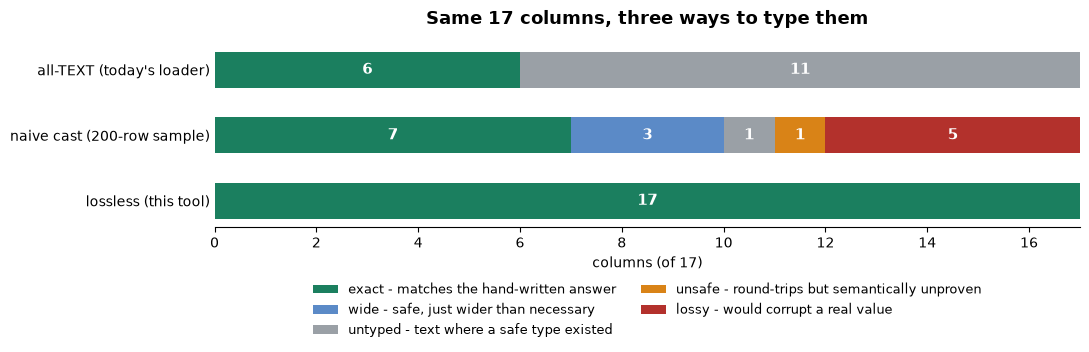

In [11]:
import matplotlib
import matplotlib.pyplot as plt

COLORS = {"exact": "#1b7f5f", "wide": "#5b8ac7", "untyped": "#9aa0a6",
          "unsafe": "#d98317", "lossy": "#b3312c"}
LABEL = {
    "exact": "exact - matches the hand-written answer",
    "wide": "wide - safe, just wider than necessary",
    "untyped": "untyped - text where a safe type existed",
    "unsafe": "unsafe - round-trips but semantically unproven",
    "lossy": "lossy - would corrupt a real value",
}
ORDER = ["exact", "wide", "untyped", "unsafe", "lossy"]

names = list(bench)
counts = {b: [sum(1 for v in bench[n].values() if v == b) for n in names] for b in ORDER}
total = len(EXPECTED)

fig, ax = plt.subplots(figsize=(11, 3.9))
left = [0.0] * len(names)
for b in ORDER:
    ax.barh(names, counts[b], left=left, color=COLORS[b], label=LABEL[b], height=0.55)
    for i, (v, l) in enumerate(zip(counts[b], left)):
        if v:
            ax.text(l + v / 2, i, str(v), ha="center", va="center",
                    color="white", fontsize=11, fontweight="bold")
    left = [l + v for l, v in zip(left, counts[b])]

ax.set_xlim(0, total)
ax.set_xlabel(f"columns (of {total})")
ax.set_title("Same 17 columns, three ways to type them", fontsize=13, fontweight="bold", pad=14)
ax.invert_yaxis()
ax.tick_params(axis="y", length=0)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=2, frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("type_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| | all-TEXT | naive cast | lossless |
|---|---|---|---|
| columns typed correctly | 6 | 7 | **17** |
| columns **silently corrupted** | 0 | **5** | **0** |
| semantically unproven casts | 0 | 1 | 0 |
| safe but wider than needed | 0 | 3 | 0 |
| left as text where a type existed | 11 | 1 | 0 |
| abstentions, **with a stated reason** | - | - | 3 |

The naive caster is not bad at parsing - it is bad at *knowing when parsing is not the question*.
All three of the abstentions (`zip_code`, `ship_date`, `legacy_amount`) are columns where the
right answer is a conversation with whoever owns the source, and the tool's job is to route it
there rather than to pick something plausible.

Two rules and one refusal. That is the entire method:

1. **Text-preserving** - the render must reproduce the source text.
2. **Value-preserving** - the stored number must equal the number written.
3. **Abstain out loud** - and say which upstream fix would settle it.

## Try your own

Point it at a real export. Everything is read as text on purpose - that is the situation being
fixed, and letting pandas infer first would hide the very defects this is looking for.

In [12]:
# import csv, io
#
# with open("your_export.csv", encoding="utf-8-sig") as fh:
#     your_rows = list(csv.DictReader(fh))          # every value stays a string
#
# your_results = infer_table(your_rows, Policy(
#     min_rows_for_not_null=25,     # raise this if the file is a small sample of a big table
#     varchar_block=8,              # round VARCHAR lengths up to a multiple of this
#     enum_max_distinct=12,         # low-cardinality strings get a CHECK-constraint suggestion
# ))
#
# print(emit_ddl("your_table", your_results, "postgres"))   # or "duckdb" / "sqlite"
# for f in all_findings(your_results):
#     print(f)
#
# # Sanity check before shipping: nothing the tool proposed should be lossy.
# assert not any(is_lossy(r.type, [row[r.name] for row in your_rows]) for r in your_results)

---

**Streamlit version** - upload a CSV, move the policy thresholds and watch the DDL and the
findings change:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) · [`data-engineering-pro/type-inferencer`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/type-inferencer)